# Modello Predittivo per l'Esito degli Incontri UFC: Un'Analisi Quantitativa e Architetturale

L'Ultimate Fighting Championship (UFC) rappresenta un ecosistema sportivo caratterizzato da un'estrema varianza stocastica, dove l'esito di un incontro dipende da una complessa interazione di variabili biometriche, storiche e tattiche.

L'obiettivo di questo progetto è la progettazione e l'implementazione di una pipeline end-to-end di Machine Learning per la classificazione binaria dell'esito dei match (Vittoria Angolo Rosso, Vittoria Angolo Blu).

Trattandosi di un problema applicato al dominio degli Sports Analytics, l'analisi affronterà sfide classiche dell'ingegneria dei dati: la gestione della sparsità informativa (Missing Data), la neutralizzazione dei bias intrinseci del dataset (come il vantaggio a priori del Red Corner), la Feature Selection per combattere la maledizione della dimensionalità e la rigorosa validazione su serie temporali (Chrono-Split e TimeSeriesSplit) per prevenire il Data Leakage.

# EDA - Exploratory Data Analysis

La prima fase del progetto è dedicata all'**Exploratory Data Analysis (EDA)**, necessaria per ispezionare la topologia dello spazio vettoriale, valutare le distribuzioni e mappare i legami lineari tra le variabili prima di procedere alla feature selection.

## Inizializzazione dell'Ambiente di Calcolo

In questa fase configuriamo l'ambiente operativo importando i framework fondamentali per il calcolo tensoriale (`numpy`), la manipolazione relazionale dei dati (`pandas`) e la visualizzazione scientifica delle distribuzioni (`matplotlib`, `seaborn`). Viene inoltre impostata una configurazione grafica standardizzata per garantire la chiarezza visiva degli output analitici.

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

# Impostazioni grafiche per una migliore leggibilità
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Show all columns
pd.set_option('display.max_columns', None)
# Show all rows
pd.set_option('display.max_rows', None)
# Increase the width of each column
pd.set_option('display.max_colwidth', None)

ufc_data = pd.read_csv('data.csv')

# Prime 5 righe
ufc_data.head()

,R_fighter,B_fighter,Referee,date,location,Winner,title_bout,weight_class,B_avg_KD,B_avg_opp_KD,B_avg_SIG_STR_pct,B_avg_opp_SIG_STR_pct,B_avg_TD_pct,B_avg_opp_TD_pct,B_avg_SUB_ATT,B_avg_opp_SUB_ATT,B_avg_REV,B_avg_opp_REV,B_avg_SIG_STR_att,B_avg_SIG_STR_landed,B_avg_opp_SIG_STR_att,B_avg_opp_SIG_STR_landed,B_avg_TOTAL_STR_att,B_avg_TOTAL_STR_landed,B_avg_opp_TOTAL_STR_att,B_avg_opp_TOTAL_STR_landed,B_avg_TD_att,B_avg_TD_landed,B_avg_opp_TD_att,B_avg_opp_TD_landed,B_avg_HEAD_att,B_avg_HEAD_landed,B_avg_opp_HEAD_att,B_avg_opp_HEAD_landed,B_avg_BODY_att,B_avg_BODY_landed,B_avg_opp_BODY_att,B_avg_opp_BODY_landed,B_avg_LEG_att,B_avg_LEG_landed,B_avg_opp_LEG_att,B_avg_opp_LEG_landed,B_avg_DISTANCE_att,B_avg_DISTANCE_landed,B_avg_opp_DISTANCE_att,B_avg_opp_DISTANCE_landed,B_avg_CLINCH_att,B_avg_CLINCH_landed,B_avg_opp_CLINCH_att,B_avg_opp_CLINCH_landed,B_avg_GROUND_att,B_avg_GROUND_landed,B_avg_opp_GROUND_att,B_avg_opp_GROUND_landed,B_avg_CTRL_time(seconds),B_avg_opp_CTRL_time(seconds),B_total_time_fought(seconds),B_total_rounds_fought,B_total_title_bouts,B_current_win_streak,B_current_lose_streak,B_longest_win_streak,B_wins,B_losses,B_draw,B_win_by_Decision_Majority,B_win_by_Decision_Split,B_win_by_Decision_Unanimous,B_win_by_KO/TKO,B_win_by_Submission,B_win_by_TKO_Doctor_Stoppage,B_Stance,B_Height_cms,B_Reach_cms,B_Weight_lbs,R_avg_KD,R_avg_opp_KD,R_avg_SIG_STR_pct,R_avg_opp_SIG_STR_pct,R_avg_TD_pct,R_avg_opp_TD_pct,R_avg_SUB_ATT,R_avg_opp_SUB_ATT,R_avg_REV,R_avg_opp_REV,R_avg_SIG_STR_att,R_avg_SIG_STR_landed,R_avg_opp_SIG_STR_att,R_avg_opp_SIG_STR_landed,R_avg_TOTAL_STR_att,R_avg_TOTAL_STR_landed,R_avg_opp_TOTAL_STR_att,R_avg_opp_TOTAL_STR_landed,R_avg_TD_att,R_avg_TD_landed,R_avg_opp_TD_att,R_avg_opp_TD_landed,R_avg_HEAD_att,R_avg_HEAD_landed,R_avg_opp_HEAD_att,R_avg_opp_HEAD_landed,R_avg_BODY_att,R_avg_BODY_landed,R_avg_opp_BODY_att,R_avg_opp_BODY_landed,R_avg_LEG_att,R_avg_LEG_landed,R_avg_opp_LEG_att,R_avg_opp_LEG_landed,R_avg_DISTANCE_att,R_avg_DISTANCE_landed,R_avg_opp_DISTANCE_att,R_avg_opp_DISTANCE_landed,R_avg_CLINCH_att,R_avg_CLINCH_landed,R_avg_opp_CLINCH_att,R_avg_opp_CLINCH_landed,R_avg_GROUND_att,R_avg_GROUND_landed,R_avg_opp_GROUND_att,R_avg_opp_GROUND_landed,R_avg_CTRL_time(seconds),R_avg_opp_CTRL_time(seconds),R_total_time_fought(seconds),R_total_rounds_fought,R_total_title_bouts,R_current_win_streak,R_current_lose_streak,R_longest_win_streak,R_wins,R_losses,R_draw,R_win_by_Decision_Majority,R_win_by_Decision_Split,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_Stance,R_Height_cms,R_Reach_cms,R_Weight_lbs,B_age,R_age
0,Adrian Yanez,Gustavo Lopez,Chris Tognoni,2021-03-20,"Las Vegas, Nevada, USA",Red,False,Bantamweight,0.000,0.0,0.420000,0.49500,0.330,0.36000,0.500,1.0000,0.00,0.0,50.0000,20.0000,84.000,45.0000,76.5000,41.000,114.000,64.00,1.500,1.0,9.0,6.500,39.500,11.000,63.0000,27.500,7.5000,7.0000,12.0000,9.0000,3.000,2.000,9.000,8.500,35.0000,12.5,43.5000,17.5000,10.5000,4.5000,4.0000,3.00,4.5000,3.000,36.50,24.50,34.00,277.5000,531.5,4,0,0,1,1,1,1,0,0,0,0,0,1,0,Orthodox,165.10,170.18,135.0,1.000000,0.000000,0.500000,0.460000,0.000000,0.00000,0.000000,0.00000,0.00000,0.00,34.000000,17.000000,13.00000,6.000000,35.000000,18.000000,16.000000,9.000000,0.000000,0.000000,3.000000,0.000000,32.00000,15.000000,11.000000,5.000000,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,33.000000,16.000000,12.000000,6.000000,1.000000,1.000000,1.0000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,54.000000,166.000000,1,0,1,0,1,1,0,0,0,0,0,1,0,0,Orthodox,170.18,177.80,135.0,31.0,27.0
1,Trevin Giles,Roman Dolidze,Herb Dean,2021-03-20,"Las Vegas, Nevada, USA",Red,False,Middleweight,0.500,0.0,0.660000,0.30500,0.300,0.50000,1.500,0.0000,0.00,0.0,65.5000,35.0000,50.000,16.5000,113.5000,68.500,68.500,29.00,2.500,1.5,0.5,0.500,46.000,20.000,36.0000,7.500,12.0000,8.0000,8.0000,3.0000,7.500,7.000,6.000,6.000,58.0000,30.0,48.0000,15.5000,0.5000,0.5000,0.5000,0.50,7

## Ispezione Strutturale e Momenti Statistici

Il primo passo dell'analisi esplorativa consiste nel caricamento in memoria della matrice dei dati e nella valutazione della sua impronta strutturale (dimensioni, tipologia dei dati e allocazione in memoria).
Successivamente, si estraggono i momenti statistici fondamentali (media, deviazione standard, valori minimi e massimi) per le variabili numeriche continue. Questa operazione permette di identificare immediatamente potenziali anomalie di scala, outlier estremi o artefatti nel campionamento.

In [29]:
print("\n--- Informazioni Strutturali ---")
print(ufc_data.info(verbose=True, show_counts=True))

print("\n--- Statistiche Descrittive (Variabili Numeriche) ---")
display(ufc_data.describe())


--- Informazioni Strutturali ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6012 entries, 0 to 6011
Data columns (total 144 columns):
 #    Column                        Non-Null Count  Dtype  
---   ------                        --------------  -----  
 0    R_fighter                     6012 non-null   object 
 1    B_fighter                     6012 non-null   object 
 2    Referee                       5980 non-null   object 
 3    date                          6012 non-null   object 
 4    location                      6012 non-null   object 
 5    Winner                        6012 non-null   object 
 6    title_bout                    6012 non-null   bool   
 7    weight_class                  6012 non-null   object 
 8    B_avg_KD                      4585 non-null   float64
 9    B_avg_opp_KD                  4585 non-null   float64
 10   B_avg_SIG_STR_pct             4585 non-null   float64
 11   B_avg_opp_SIG_STR_pct         4585 non-null   float64
 12   B_avg_TD_pct

,B_avg_KD,B_avg_opp_KD,B_avg_SIG_STR_pct,B_avg_opp_SIG_STR_pct,B_avg_TD_pct,B_avg_opp_TD_pct,B_avg_SUB_ATT,B_avg_opp_SUB_ATT,B_avg_REV,B_avg_opp_REV,B_avg_SIG_STR_att,B_avg_SIG_STR_landed,B_avg_opp_SIG_STR_att,B_avg_opp_SIG_STR_landed,B_avg_TOTAL_STR_att,B_avg_TOTAL_STR_landed,B_avg_opp_TOTAL_STR_att,B_avg_opp_TOTAL_STR_landed,B_avg_TD_att,B_avg_TD_landed,B_avg_opp_TD_att,B_avg_opp_TD_landed,B_avg_HEAD_att,B_avg_HEAD_landed,B_avg_opp_HEAD_att,B_avg_opp_HEAD_landed,B_avg_BODY_att,B_avg_BODY_landed,B_avg_opp_BODY_att,B_avg_opp_BODY_landed,B_avg_LEG_att,B_avg_LEG_landed,B_avg_opp_LEG_att,B_avg_opp_LEG_landed,B_avg_DISTANCE_att,B_avg_DISTANCE_landed,B_avg_opp_DISTANCE_att,B_avg_opp_DISTANCE_landed,B_avg_CLINCH_att,B_avg_CLINCH_landed,B_avg_opp_CLINCH_att,B_avg_opp_CLINCH_landed,B_avg_GROUND_att,B_avg_GROUND_landed,B_avg_opp_GROUND_att,B_avg_opp_GROUND_landed,B_avg_CTRL_time(seconds),B_avg_opp_CTRL_time(seconds),B_total_time_fought(seconds),B_total_rounds_fought,B_total_title_bouts,B_current_win_streak,B_current_lose_streak,B_longest_win_streak,B_wins,B_losses,B_draw,B_win_by_Decision_Majority,B_win_by_Decision_Split,B_win_by_Decision_Unanimous,B_win_by_KO/TKO,B_win_by_Submission,B_win_by_TKO_Doctor_Stoppage,B_Height_cms,B_Reach_cms,B_Weight_lbs,R_avg_KD,R_avg_opp_KD,R_avg_SIG_STR_pct,R_avg_opp_SIG_STR_pct,R_avg_TD_pct,R_avg_opp_TD_pct,R_avg_SUB_ATT,R_avg_opp_SUB_ATT,R_avg_REV,R_avg_opp_REV,R_avg_SIG_STR_att,R_avg_SIG_STR_landed,R_avg_opp_SIG_STR_att,R_avg_opp_SIG_STR_landed,R_avg_TOTAL_STR_att,R_avg_TOTAL_STR_landed,R_avg_opp_TOTAL_STR_att,R_avg_opp_TOTAL_STR_landed,R_avg_TD_att,R_avg_TD_landed,R_avg_opp_TD_att,R_avg_opp_TD_landed,R_avg_HEAD_att,R_avg_HEAD_landed,R_avg_opp_HEAD_att,R_avg_opp_HEAD_landed,R_avg_BODY_att,R_avg_BODY_landed,R_avg_opp_BODY_att,R_avg_opp_BODY_landed,R_avg_LEG_att,R_avg_LEG_landed,R_avg_opp_LEG_att,R_avg_opp_LEG_landed,R_avg_DISTANCE_att,R_avg_DISTANCE_landed,R_avg_opp_DISTANCE_att,R_avg_opp_DISTANCE_landed,R_avg_CLINCH_att,R_avg_CLINCH_landed,R_avg_opp_CLINCH_att,R_avg_opp_CLINCH_landed,R_avg_GROUND_att,R_avg_GROUND_landed,R_avg_opp_GROUND_att,R_avg_opp_GROUND_landed,R_avg_CTRL_time(seconds),R_avg_opp_CTRL_time(seconds),R_total_time_fought(seconds),R_total_rounds_fought,R_total_title_bouts,R_current_win_streak,R_current_lose_streak,R_longest_win_streak,R_wins,R_losses,R_draw,R_win_by_Decision_Majority,R_win_by_Decision_Split,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_Height_cms,R_Reach_cms,R_Weight_lbs,B_age,R_age
count,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.00000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,6012.000000,6012.000000,6012.000000,6012.000000,6012.000000,6012.000000,6012.000000,6012.0,6012.000000,6012.000000,6012.000000,6012.000000,6012.000000,6012.000000,6002.000000,5121.000000,6004.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.00000,5300.000000,5300.000000,5300.000000,5300.000000,6012.000000,6012.000000,6012.000000,6012.000000,6012.000000,6012.000000,6012.000000,6012

## Analisi della Sparsità dei Dati

Nei dataset del mondo reale, l'assenza di dati è la norma, non l'eccezione. In questo blocco quantifichiamo la sparsità della matrice calcolando la percentuale di valori nulli (`NaN`) per ciascuna feature.
Comprendere se l'assenza di un dato è un errore di registrazione o se porta con sé un'informazione strutturale (ad esempio l'assenza di statistiche storiche per i lottatori debuttanti) è cruciale per definire le successive strategie di Imputation e prevenire la distorsione dell'algoritmo.


--- Maggiori 20 Colonne con più Valori Mancanti (%) ---
                          Missing Count  Percentage
B_avg_opp_SUB_ATT                  1427   23.735862
B_avg_SUB_ATT                      1427   23.735862
B_avg_opp_TD_pct                   1427   23.735862
B_avg_TD_pct                       1427   23.735862
B_avg_opp_SIG_STR_pct              1427   23.735862
B_avg_SIG_STR_pct                  1427   23.735862
B_avg_opp_KD                       1427   23.735862
B_avg_KD                           1427   23.735862
B_avg_TOTAL_STR_landed             1427   23.735862
B_avg_TOTAL_STR_att                1427   23.735862
B_avg_opp_SIG_STR_landed           1427   23.735862
B_avg_opp_SIG_STR_att              1427   23.735862
B_avg_SIG_STR_landed               1427   23.735862
B_avg_SIG_STR_att                  1427   23.735862
B_avg_opp_REV                      1427   23.735862
B_avg_REV                          1427   23.735862
B_avg_opp_CLINCH_att               1427   23.735862
B_avg_o

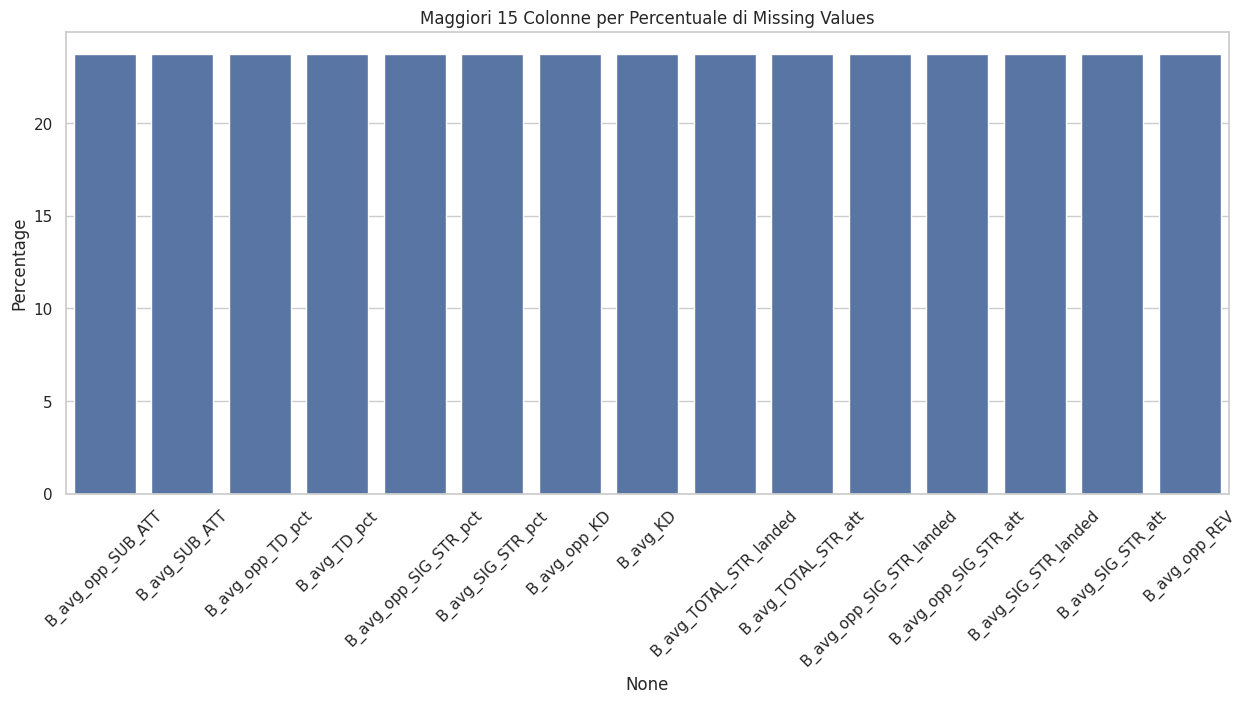

In [30]:
missing_values = ufc_data.isnull().sum().sort_values(ascending=False)
missing_percent = (missing_values / len(ufc_data)) * 100

print("\n--- Maggiori 20 Colonne con più Valori Mancanti (%) ---")
missing_ufc_data = pd.concat([missing_values, missing_percent], axis=1, keys=['Missing Count', 'Percentage'])
print(missing_ufc_data.head(20))

# Visualizzazione dei Missing Values (se rilevanti)
plt.figure(figsize=(15, 6))
sns.barplot(x=missing_ufc_data.head(15).index, y=missing_ufc_data.head(15)['Percentage'])
plt.xticks(rotation=45)
plt.title("Maggiori 15 Colonne per Percentuale di Missing Values")
plt.show()

## Analisi Univariata della Variabile Dipendente (Target)

Il cuore di un sistema di classificazione è la variabile dipendente $y$.

L'analisi della distribuzione delle classi bersaglio (Blue, Red, Draw) evidenzia immediatamente un problema strutturale del dominio UFC: lo **Sbilanciamento delle Classi (Class Imbalance)**.

Storicamente, il Red Corner (assegnato ai campioni in carica o ai favoriti) vince con una frequenza significativamente maggiore. Questa probabilità a priori dovrà essere gestita in fase di modellazione per evitare che gli algoritmi si appiattiscano sulla predizione della classe maggioritaria.

/tmp/ipykernel_294/1770925918.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ufc_data, x='Winner', palette='viridis')


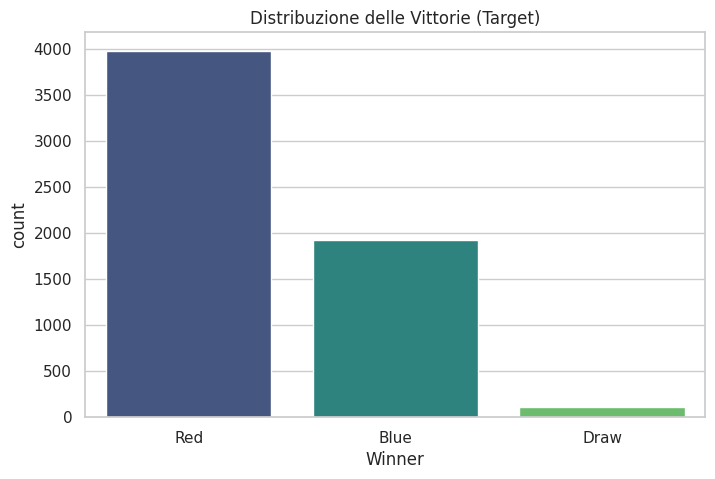


--- Percentuale di Vittorie ---
Winner
Red     66.184298
Blue    31.986028
Draw     1.829674
Name: proportion, dtype: float64


In [31]:
plt.figure(figsize=(8, 5))
sns.countplot(data=ufc_data, x='Winner', palette='viridis')
plt.title("Distribuzione delle Vittorie (Target)")
plt.show()
# Visualizza percentuale Red Winner, Blue Winner, Draw
winner_percentages = ufc_data['Winner'].value_counts(normalize=True) * 100
print("\n--- Percentuale di Vittorie ---")
print(winner_percentages)

## Analisi Bivariata: L'Impatto del Contesto

Esploriamo la relazione tra la variabile target e il contesto del match, distinguendo tra incontri validi per il titolo e incontri regolari.

L'obiettivo è verificare se l'asimmetria delle vittorie (il bias del Red Corner) subisce variazioni statisticamente rilevanti quando la pressione competitiva e il livello tecnico sono ai massimi livelli (incontri titolati, generalmente a 5 round).

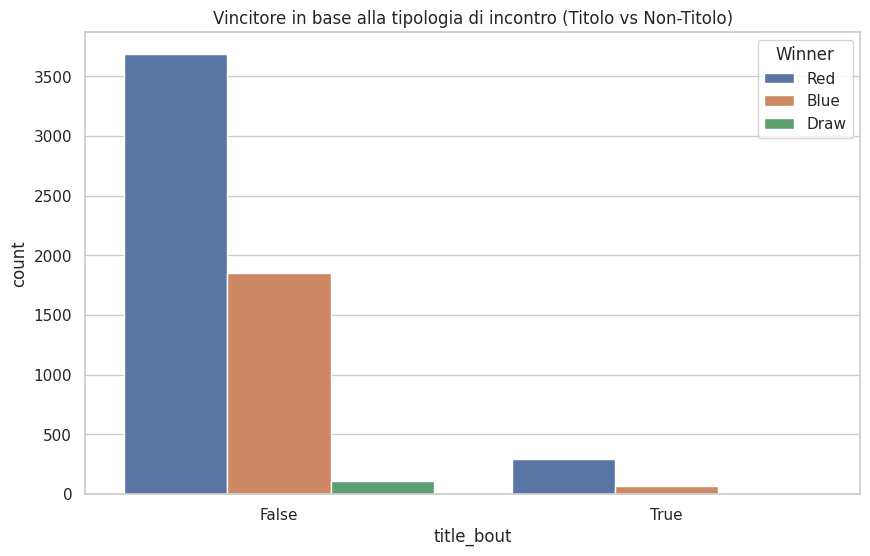

In [32]:
#Relazione tra Winner e title_bout
plt.figure(figsize=(10, 6))
sns.countplot(data=ufc_data, x='title_bout', hue='Winner')
plt.title("Vincitore in base alla tipologia di incontro (Titolo vs Non-Titolo)")
plt.show()

## Analisi Bivariata: Distribuzione per Classi di Peso

Le MMA sono rigidamente segmentate in classi di peso.

Questa visualizzazione traccia l'esito dei match attraverso lo spettro delle categorie fisiche. Si indaga se il tasso di vittoria dell'angolo rosso sia omogeneo su tutto il dominio o se vi siano categorie specifiche (es. pesi massimi, caratterizzati da altissima stocasticità) in cui le dinamiche predittive si discostano dalla media globale.

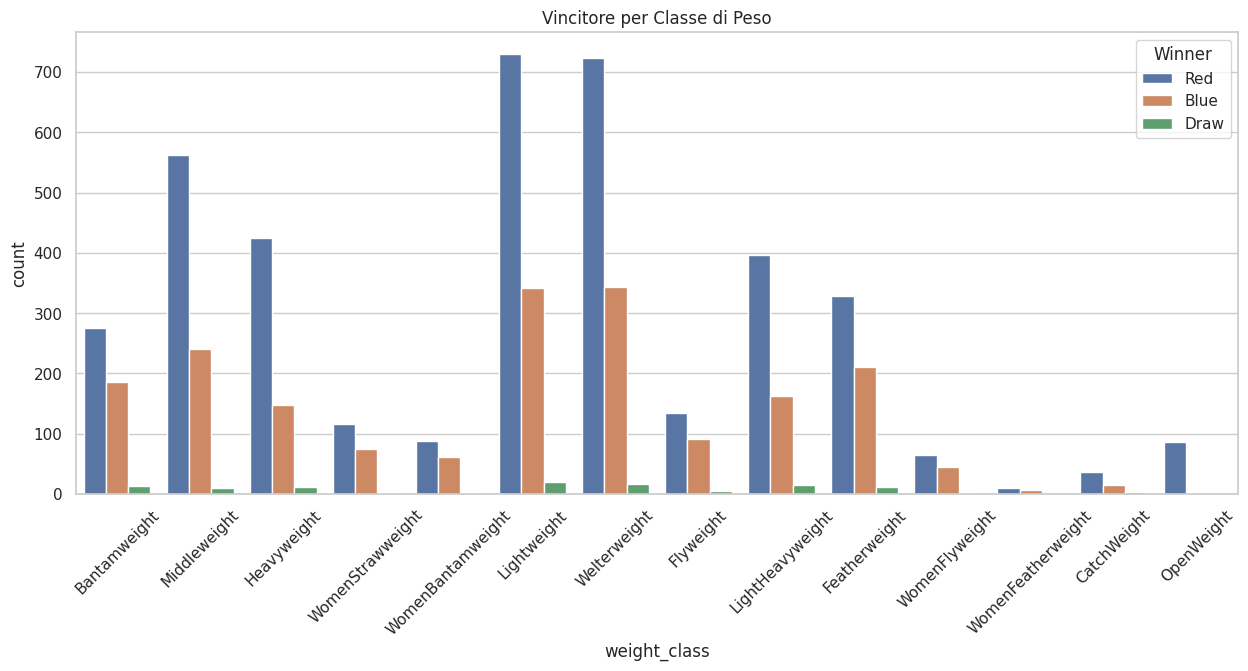

In [33]:
# Relazione tra Weight Class e Winner
plt.figure(figsize=(15, 6))
sns.countplot(data=ufc_data, x='weight_class', hue='Winner')
plt.xticks(rotation=45)
plt.title("Vincitore per Classe di Peso")
plt.show()

## Matrice di Correlazione (Feature Biometriche)

Data l'elevata dimensionalità del dataset, si isola un sotto-tensore contenente le principali metriche assolute (età, altezza, allungo, peso e storico vittorie) per calcolarne la matrice di covarianza/correlazione.
Questa operazione è propedeutica per l'identificazione di **Multicollinearità**: variabili che condividono un'altissima correlazione lineare (es. altezza e allungo) potrebbero destabilizzare gli iperpiani decisionali dei modelli lineari, suggerendo la necessità di future riduzioni dimensionali o regolarizzazioni penalizzate.

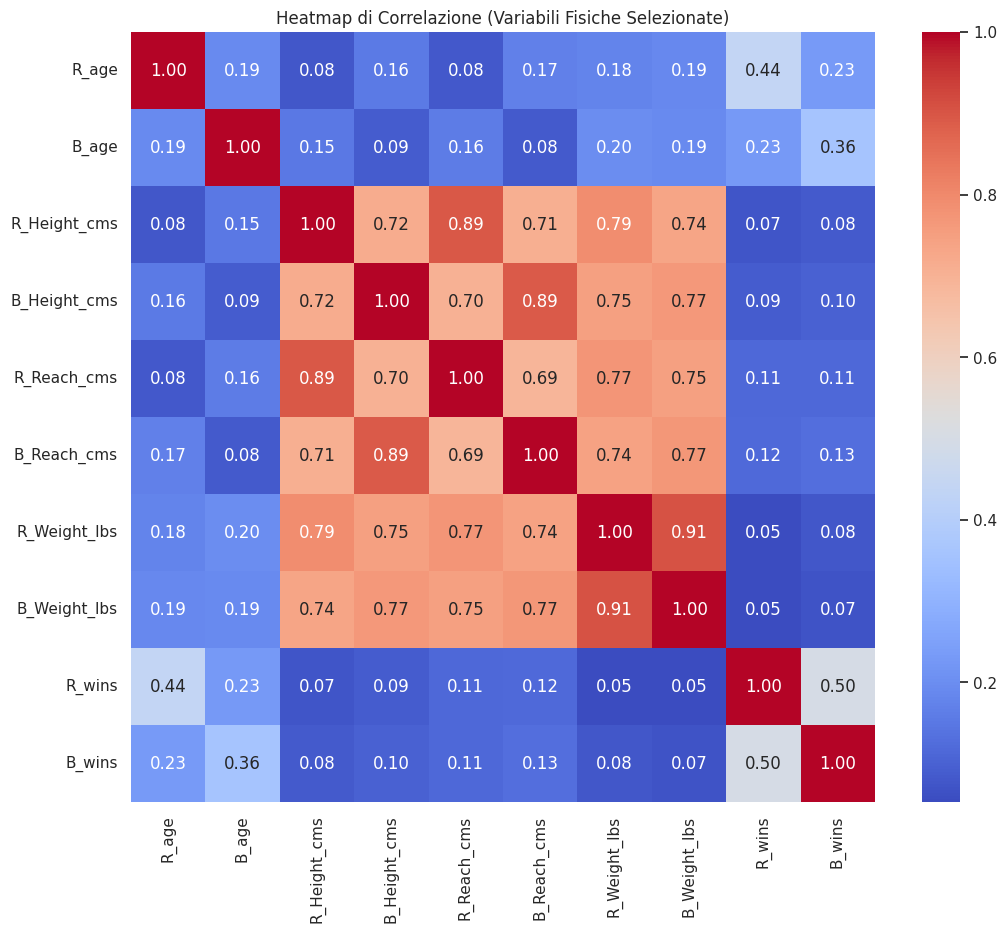

In [34]:
# --- Correlazione Preliminare ---
# Data l'alta dimensionalità, isoliamo un subset di variabili fisiche e di record
physical_cols = [
    'R_age', 'B_age',
    'R_Height_cms', 'B_Height_cms',
    'R_Reach_cms', 'B_Reach_cms',
    'R_Weight_lbs', 'B_Weight_lbs',
    'R_wins', 'B_wins'
]

plt.figure(figsize=(12, 10))
corr_matrix = ufc_data[physical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap di Correlazione (Variabili Fisiche Selezionate)")
plt.show()

## Analisi Distribuzionale: L'Impatto del Decadimento Biologico (Età)

L'età rappresenta uno dei fattori limitanti più critici negli sport da combattimento. Tramite l'uso di grafici a scatola (*Boxplot*), si mettono a confronto le distribuzioni anagrafiche dei vincitori e degli sconfitti. L'estrazione delle mediane e dei quartili permette di osservare visivamente come l'età (e il conseguente delta anagrafico tra i lottatori) influisca sulle probabilità di successo, identificando le finestre temporali di picco atletico.

/tmp/ipykernel_294/4239089006.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ufc_data, x='Winner', y='R_age', palette='Set1')
/tmp/ipykernel_294/4239089006.py:13: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=ufc_data[ufc_data['Winner'] == 'Red']['R_age'], label='Vincitore Red', shade=True)
/tmp/ipykernel_294/4239089006.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=ufc_data[ufc_data['Winner'] == 'Blue']['R_age'], label='Vincitore Blue', shade=True)


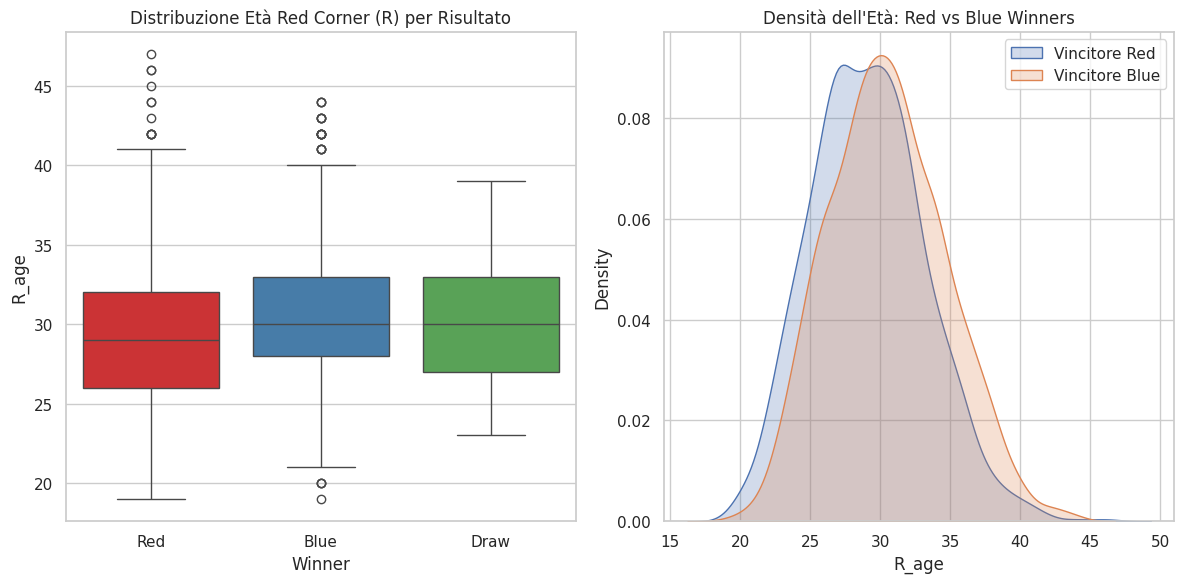

In [35]:
# Vedere la distribuzione dell'Età rispetto al Vincitore
# Creiamo un dataframe "lungo" per confrontare l'età dei vincitori vs perdenti
# Analizziamo l'età del Red Corner (R_age) in base al risultato (Winner)
plt.figure(figsize=(12, 6))

# Boxplot per vedere mediana e quartili
plt.subplot(1, 2, 1)
sns.boxplot(data=ufc_data, x='Winner', y='R_age', palette='Set1')
plt.title('Distribuzione Età Red Corner (R) per Risultato')

# KDE Plot per vedere la "forma" della distribuzione
plt.subplot(1, 2, 2)
sns.kdeplot(data=ufc_data[ufc_data['Winner'] == 'Red']['R_age'], label='Vincitore Red', shade=True)
sns.kdeplot(data=ufc_data[ufc_data['Winner'] == 'Blue']['R_age'], label='Vincitore Blue', shade=True)
plt.title('Densità dell\'Età: Red vs Blue Winners')
plt.legend()

plt.tight_layout()
plt.show()

## Analisi Frequenziale Volumetrica (Weight Class)

Si conclude l'esplorazione estraendo il volume totale di istanze (match) per ciascuna categoria di peso. Questa scansione volumetrica è essenziale per assicurarsi che i segmenti nominali del dataset possiedano una numerosità campionaria statisticamente sufficiente.

Classi di peso con frequenze marginali eccessivamente basse potrebbero generare rumore durante la successiva fase di One-Hot Encoding.

In [36]:
# Usiamo la funzione value_counts()
# Questa funzione conta quante volte appare ogni categoria nella colonna 'weight_class'
conteggio_classi = ufc_data['weight_class'].value_counts()

print("Numero di match per ogni categoria di peso:")
print(conteggio_classi)

Numero di match per ogni categoria di peso:
weight_class
Lightweight           1091
Welterweight          1083
Middleweight           813
Heavyweight            585
LightHeavyweight       573
Featherweight          551
Bantamweight           475
Flyweight              230
WomenStrawweight       192
WomenBantamweight      151
WomenFlyweight         112
OpenWeight              86
CatchWeight             54
WomenFeatherweight      16
Name: count, dtype: int64


# Data Cleaning

## Operazioni Stateless e Preparazione Temporale

Prima di isolare il set di test, applichiamo le trasformazioni deterministiche (Stateless) all'intero dataset. Queste operazioni non generano Data Leakage poiché non si basano su calcoli statistici globali.

**Ordinamento Cronologico:** Condizione necessaria per garantire la validità del successivo *Chrono-Split*.

**Filtraggio Dominio:** Rimozione dei pareggi e di colonne superflue (arbitro, location).

## Gestione Debuttanti
Dobbiamo dire al modello che l'assenza di record storici significa "Debuttante". Creiamo due nuove colonne (R_is_debutant, B_is_debutant) e poi azzeriamo i `NaN` nelle statistiche.

**Drop Missing Values Critici:** Rimozione delle istanze prive di età anagrafica o di variabile target, in quanto non approssimabili in modo affidabile senza distorcere il dominio.

## Pulizia Finale (Età e Target)

L'età è un parametro biologico critico. Poiché solitamente i valori mancanti qui sono rarissimi (la UFC registra sempre l'età), inserire una mediana altererebbe i pattern anagrafici senza un reale beneficio statistico. Eliminiamo le righe dove manca l'età.

In [37]:
# --- PREPARAZIONE TEMPORALE E ORDINAMENTO ---
# Convertiamo la colonna date nel formato datetime e ordiniamo dal più vecchio al più recente
ufc_data['date'] = pd.to_datetime(ufc_data['date'])
ufc_data = ufc_data.sort_values(by='date').reset_index(drop=True)

# --- PULIZIA DOMINIO (Pareggi e Colonne Inutili) ---
ufc_data = ufc_data[ufc_data['Winner'] != 'Draw'].copy()
colonne_da_eliminare = ['Referee', 'location']
ufc_data.drop(columns=colonne_da_eliminare, inplace=True, errors='ignore')

# ---  GESTIONE DEBUTTANTI (Zero-Imputation Stateless) ---
# Identifichiamo le colonne delle performance (escludendo età e parametri fisici)
colonne_fisiche_eta = ['R_Height_cms', 'B_Height_cms', 'R_Reach_cms', 'B_Reach_cms',
                       'R_Weight_lbs', 'B_Weight_lbs', 'R_age', 'B_age']

# Selezioniamo tutte le colonne numeriche che non sono fisiche o legate all'età
colonne_statistiche = [col for col in ufc_data.select_dtypes(include=np.number).columns
                       if col not in colonne_fisiche_eta]

# Per i debuttanti, l'assenza di statistiche corrisponde matematicamente a 0
ufc_data[colonne_statistiche] = ufc_data[colonne_statistiche].fillna(0)

# --- PULIZIA FINALE (Età e Target) ---
# Se manca l'età, non possiamo calcolare l'impatto del decadimento biologico. Scartiamo la riga.
ufc_data.dropna(subset=['R_age', 'B_age', 'Winner'], inplace=True)

# Re-indicizziamo il DataFrame dopo le rimozioni per garantire il corretto funzionamento di .iloc
ufc_data = ufc_data.reset_index(drop=True)

print(f"Pulizia Stateless completata. Dimensioni attuali: {ufc_data.shape}")

Pulizia Stateless completata. Dimensioni attuali: (5710, 142)


## Fase di Splitting e Operazioni Stateful (Prevenzione Leakage)

Avendo purificato la struttura base del dataset, procediamo alla separazione cronologica (*Chrono-Split*). Da questo punto in avanti, il *Test Set* diviene inaccessibile per qualsiasi calcolo statistico.
L'imputazione dei dati fisici mancanti (Altezza, Allungo, Peso) verrà gestita in modalità *Stateful*: calcoleremo le mediane raggruppate per classe di peso esclusivamente sul *Train Set*, utilizzandole come dizionario di mappatura sia per il Train che per il Test.

In [38]:
# --- CHRONO-SPLIT (Isolamento del Futuro) ---
# Estraiamo l'80% dei dati (storico) per l'addestramento e il 20% (futuro) per il test
split_index = int(len(ufc_data) * 0.8)

train_data = ufc_data.iloc[:split_index].copy()
test_data = ufc_data.iloc[split_index:].copy()

print(f"Dimensione Train Set: {train_data.shape}")
print(f"Dimensione Test Set: {test_data.shape}")

# --- IMPUTAZIONE DATI FISICI (Stateful su Train Set) ---
colonne_fisiche = ['R_Height_cms', 'B_Height_cms', 'R_Reach_cms', 'B_Reach_cms', 'R_Weight_lbs', 'B_Weight_lbs']

# Calcoliamo i momenti statistici (mediana) SOLO SUL TRAIN SET
mediane_train = train_data.groupby('weight_class')[colonne_fisiche].median()

def imputa_fisici(df, mediane_apprese):
    """
    Funzione per iniettare le mediane apprese dal Train Set all'interno di un DataFrame target,
    rispettando la segmentazione per categoria di peso.
    """
    df_imputed = df.copy()
    for wc in mediane_apprese.index:
        mask = df_imputed['weight_class'] == wc
        for col in colonne_fisiche:
            # Riempi i NaN della specifica weight class con la mediana appresa dal Train
            df_imputed.loc[mask, col] = df_imputed.loc[mask, col].fillna(mediane_apprese.loc[wc, col])

    # Nel caso rarissimo in cui rimangano NaN (es. lottatore Catchweight non presente nel train)
    df_imputed.dropna(subset=colonne_fisiche, inplace=True)
    return df_imputed

# Proiettiamo la conoscenza appresa su entrambi i tensori
train_data = imputa_fisici(train_data, mediane_train)
test_data = imputa_fisici(test_data, mediane_train)

print(f"Imputazione fisica completata (Zero Leakage).")

Dimensione Train Set: (4568, 142)
Dimensione Test Set: (1142, 142)
Imputazione fisica completata (Zero Leakage).


Prima di passare al Feature Selection, dobbiamo "chiudere i buchi".

In [39]:
# Identifichiamo quali colonne contengono ancora NaN
nan_residui = ufc_data.isnull().sum()
colonne_con_nan = nan_residui[nan_residui > 0]
print("Colonne con NaN residui e relative quantità:")
print(colonne_con_nan)

Colonne con NaN residui e relative quantità:
B_Stance         39
B_Height_cms      2
B_Reach_cms     693
R_Stance         22
R_Reach_cms     262
dtype: int64


Le anomalie residue individuate nel dataset sono limitate e riconducibili a cause ben definite, coerenti con il dominio applicativo.

Le variabili `B_total_time_fought` e `R_total_time_fought` presentano valori mancanti di tipo MNAR (Missing Not At Random), legati alla presenza di lottatori debuttanti che non hanno ancora accumulato tempo combattuto in UFC. In questo caso il dato non è realmente sconosciuto, ma strutturalmente assente: per un debuttante il tempo combattuto è logicamente pari a zero. È quindi stata applicata una zero imputation, scelta coerente sia dal punto di vista semantico sia modellistico.
**(Zero Imputation)**

Per quanto riguarda `B_Stance` e `R_Stance`, i valori mancanti sono classificabili come MCAR (Missing Completely At Random), poiché l’informazione sulla guardia non è stata registrata per un numero molto ridotto di atleti (circa l’1% del dataset). Data la bassa incidenza e la forte predominanza della categoria “Orthodox” (oltre il 75% dei casi), è stata adottata una **mode imputation**. La creazione di una categoria aggiuntiva come “Unknown” avrebbe introdotto una dimensione scarsamente popolata, potenzialmente penalizzante per modelli di regressione o alberi decisionali.

Infine, la variabile `B_Reach_cms` presenta un numero molto limitato di valori mancanti dovuti al fallimento dell’imputazione tramite mediana condizionata per `weight_class`. In alcuni incontri (ad esempio catchweight), l’intero sottogruppo risultava composto da valori NaN, rendendo impossibile il calcolo della mediana locale. In questi casi è stata applicata una fallback imputation utilizzando la mediana globale del dataset. Considerato che le righe coinvolte sono solo 12, l’impatto sul bias complessivo del modello è statisticamente trascurabile.

Nel complesso, le anomalie residue sono circoscritte, spiegabili e trattate con strategie di imputazione coerenti.

In [40]:
# --- PULIZIA RESIDUALE ---

# Zero Imputation per il tempo combattuto dei debuttanti
ufc_data['B_total_time_fought(seconds)'] = ufc_data['B_total_time_fought(seconds)'].fillna(0)
ufc_data['R_total_time_fought(seconds)'] = ufc_data['R_total_time_fought(seconds)'].fillna(0)

# Mode Imputation per la guardia (Stance)
# Usiamo [0] per estrarre il primo valore della series restituita dalla funzione mode()
b_stance_mode = ufc_data['B_Stance'].mode()[0]
r_stance_mode = ufc_data['R_Stance'].mode()[0]

ufc_data['B_Stance'] = ufc_data['B_Stance'].fillna(b_stance_mode)
ufc_data['R_Stance'] = ufc_data['R_Stance'].fillna(r_stance_mode)

# Fallback Imputation (Mediana Globale) per i Reach anomali residui
b_reach_global_median = ufc_data['B_Reach_cms'].median()
ufc_data['B_Reach_cms'] = ufc_data['B_Reach_cms'].fillna(b_reach_global_median)

# Controllo finale assoluto
totale_nan_rimanenti = ufc_data.isnull().sum().sum()
print(f"Dataset pulito. Valori NaN residui assoluti: {totale_nan_rimanenti}")

Dataset pulito. Valori NaN residui assoluti: 264


# Feature Engineering
Creiamo una funzione che automatizza il calcolo dei differenziali per tutte le coppie `R_*` e `B_*:`.

In [41]:
def create_differential_features(df):
    """
    Calcola i differenziali tra le statistiche di Red e Blue.
    """
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    df_numeric = df.select_dtypes(include=numerics)

    r_cols = [col for col in df_numeric.columns if col.startswith('R_')]

    for r_col in r_cols:
        b_col = 'B_' + r_col[2:]

        if b_col in df.columns:
            diff_name = 'diff_' + r_col[2:]
            df[diff_name] = df[r_col] - df[b_col]
            df.drop(columns=[r_col, b_col], inplace=True)

    return df

train_data = create_differential_features(train_data)
test_data = create_differential_features(test_data)

print(f"Dimensione attesa colonne. Colonne attuali: {train_data.shape[1]}")

Dimensione attesa colonne. Colonne attuali: 75


In [42]:
print(f"Feature Engineering completato. Nuove colonne: {train_data.columns.tolist()}")

Feature Engineering completato. Nuove colonne: ['R_fighter', 'B_fighter', 'date', 'Winner', 'title_bout', 'weight_class', 'B_Stance', 'R_Stance', 'diff_avg_KD', 'diff_avg_opp_KD', 'diff_avg_SIG_STR_pct', 'diff_avg_opp_SIG_STR_pct', 'diff_avg_TD_pct', 'diff_avg_opp_TD_pct', 'diff_avg_SUB_ATT', 'diff_avg_opp_SUB_ATT', 'diff_avg_REV', 'diff_avg_opp_REV', 'diff_avg_SIG_STR_att', 'diff_avg_SIG_STR_landed', 'diff_avg_opp_SIG_STR_att', 'diff_avg_opp_SIG_STR_landed', 'diff_avg_TOTAL_STR_att', 'diff_avg_TOTAL_STR_landed', 'diff_avg_opp_TOTAL_STR_att', 'diff_avg_opp_TOTAL_STR_landed', 'diff_avg_TD_att', 'diff_avg_TD_landed', 'diff_avg_opp_TD_att', 'diff_avg_opp_TD_landed', 'diff_avg_HEAD_att', 'diff_avg_HEAD_landed', 'diff_avg_opp_HEAD_att', 'diff_avg_opp_HEAD_landed', 'diff_avg_BODY_att', 'diff_avg_BODY_landed', 'diff_avg_opp_BODY_att', 'diff_avg_opp_BODY_landed', 'diff_avg_LEG_att', 'diff_avg_LEG_landed', 'diff_avg_opp_LEG_att', 'diff_avg_opp_LEG_landed', 'diff_avg_DISTANCE_att', 'diff_avg_DIS

Aggiungiamo una nuova colonna ad entrambi i dataset `is_same_stance`, così da informare il modello, se i due fighter hanno la stessa guardia oppure no.
Eliminiamo inoltre le colonne rimanenti `R_fighter`, `B_fighter`, `date`, `R_Stance`, `B_Stance`.

In [43]:
# Feature Interaction
# Se le guardie sono identiche, restituisce True, convertito poi in 1. Altrimenti 0.
train_data['is_same_stance'] = (train_data['R_Stance'] == train_data['B_Stance']).astype(int)
test_data['is_same_stance'] = (test_data['R_Stance'] == test_data['B_Stance']).astype(int)

# Eliminazione Identificatori e Variabili Obsolete
colonne_da_rimuovere = ['R_fighter', 'B_fighter', 'date', 'R_Stance', 'B_Stance']

# errors='ignore' evita blocchi se la cella viene eseguita due volte per sbaglio
train_data.drop(columns=colonne_da_rimuovere, inplace=True, errors='ignore')
test_data.drop(columns=colonne_da_rimuovere, inplace=True, errors='ignore')

In questa sezione procediamo alla trasformazione delle variabili semantiche e testuali in formati numerici digeribili dagli algoritmi di Machine Learning. L'obiettivo è preparare i tensori $X$ (feature) e i vettori $y$ (target) garantendo che non vi sia induzione di false relazioni ordinali (tramite One-Hot Encoding) e che le dimensioni matriciali tra Train e Test rimangano rigorosamente allineate per consentire il futuro prodotto scalare.

In [44]:
# Encoding del Target (Winner)
# Il LabelEncoder mappa alfabeticamente: Blue=0, Red=1
le_winner = LabelEncoder()
train_data['Winner'] = le_winner.fit_transform(train_data['Winner'])
test_data['Winner'] = le_winner.transform(test_data['Winner'])

# Assicuriamoci che title_bout sia numerico intero (0 o 1)
train_data['title_bout'] = train_data['title_bout'].astype(int)
test_data['title_bout'] = test_data['title_bout'].astype(int)

### One-Hot Encoding e Allineamento Matrici
Le categorie nominali (come la classe di peso) non possiedono un ordine gerarchico matematico. Per evitare che l'algoritmo deduca una distanza maggiore tra classi codificate con numeri distanti, proiettiamo queste variabili in uno spazio ortogonale binario. Successivamente, implementiamo un meccanismo di Fallback (reindex) per prevenire lo Shape Mismatch Error nel caso in cui il Test Set non presenti tutte le categorie presenti nel Train Set.

In [45]:
# --- ORTOGONALIZZAZIONE (ONE-HOT ENCODING) ---
# Convertiamo la classe di peso in matrici sparse binarie (es. weight_Lightweight = 1 o 0)
train_data = pd.get_dummies(train_data, columns=['weight_class'], prefix='weight', dtype=int)
test_data = pd.get_dummies(test_data, columns=['weight_class'], prefix='weight', dtype=int)

# ---  ALLINEAMENTO DIMENSIONALE DEI TENSORI ---
# Interfaccia di sicurezza: forziamo la matrice di Test ad avere le stesse esatte colonne
# della matrice di Train. Se una classe di peso vista nel passato (Train) non è presente
# nel futuro (Test), la colonna viene creata e riempita di zeri (fill_value=0).
test_data = test_data.reindex(columns=train_data.columns, fill_value=0)

# Verifica dimensionale (Assertion)
assert train_data.shape[1] == test_data.shape[1], "Errore Critico: Le dimensioni (colonne) di Train e Test non coincidono."

### Standardizzazione (Z-Score)
I modelli di Machine Learning richiedono feature scalate per calcolare in modo non distorto le distanze metriche o per ottimizzare la discesa del gradiente. Applichiamo lo *Z-Score* esclusivamente alle variabili numeriche continue, mantenendo intatte le variabili booleane per non perderne l'interpretabilità. Al fine di prevenire il Data Preparation Leakage, la media ($\mu$) e la deviazione standard ($\sigma$) vengono apprese unicamente dal Train Set e successivamente applicate al Test Set.

In [46]:
from sklearn.preprocessing import StandardScaler

# Selezioniamo solo le feature continue (i differenziali)
feature_da_scalare = [col for col in train_data.columns if col.startswith('diff_')]

# Inizializziamo lo StandardScaler
scaler = StandardScaler()

# FIT_TRANSFORM sul Train Set: l'algoritmo mappa mu e sigma dal passato, scalando i vettori
train_data[feature_da_scalare] = scaler.fit_transform(train_data[feature_da_scalare])

# SOLO TRANSFORM sul Test Set: applichiamo i parametri del Train Set sui dati futuri
test_data[feature_da_scalare] = scaler.transform(test_data[feature_da_scalare])

# Controllo Assoluto: Verifica che non ci siano tipi di dato non numerici (Object)
# e che la standardizzazione sia andata a buon fine
print("--- Standardizzazione Completata ---")
print(f"Dimensioni finali X_train: {train_data.drop(columns=['Winner']).shape}")
print(f"Dimensioni finali X_test:  {test_data.drop(columns=['Winner']).shape}")

residui_testuali = train_data.select_dtypes(include=['object']).columns.tolist()
if len(residui_testuali) == 0:
    print("Test Superato: Tutti i dati sono in formato vettoriale numerico.")
else:
    print(f"Attenzione, colonne testuali residue: {residui_testuali}")

--- Standardizzazione Completata ---
Dimensioni finali X_train: (4556, 82)
Dimensioni finali X_test:  (1142, 82)
Test Superato: Tutti i dati sono in formato vettoriale numerico.


# Preparazione dei dati per il Machine Learning

**Separazione Features (X) e Target (y)**: Il dataset `train_data` e `test_data` viene diviso in due parti:
    *   `X_train` e `X_test` contengono le **features** (o variabili indipendenti), cioè tutte le colonne del dataset ad eccezione della colonna 'Winner'. Queste sono le informazioni che il modello utilizzerà per fare le sue previsioni.
    *   `y_train` e `y_test` contengono il **target** (o variabile dipendente), che in questo caso è la colonna 'Winner'. Questa è la variabile che il modello dovrà imparare a prevedere.

**Visualizzazione Dimensioni**: Le istruzioni `print` mostrano le dimensioni (numero di righe e colonne) dei set di training e test. Questo è utile per verificare che la separazione sia avvenuta correttamente.

In [47]:
# --- SEPARAZIONE DEI TENSORI X E y ---
# Estraiamo le features (X) eliminando la colonna target
X_train = train_data.drop(columns=['Winner'])
X_test = test_data.drop(columns=['Winner'])

# Estraiamo il vettore target (y)
y_train = train_data['Winner']
y_test = test_data['Winner']

print(f"Dimensioni X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Dimensioni X_test: {X_test.shape}, y_test: {y_test.shape}")

Dimensioni X_train: (4556, 82), y_train: (4556,)
Dimensioni X_test: (1142, 82), y_test: (1142,)


## Embedded Feature Selection tramite Regolarizzazione L1

L'introduzione della *Context Injection* ha espanso ulteriormente l'alta dimensionalità del dataset, aggravando il rischio di *Overfitting* sui modelli non lineari (Curse of Dimensionality).
Per distillare il segnale dal rumore, implementiamo una tecnica di riduzione dimensionale Embedded. Utilizziamo un regressore logistico con **Penalità L1 (Lasso)**. La geometria a "rombo" dello spazio dei vincoli L1 forza i coefficienti delle variabili debolmente correlate o ridondanti esattamente a zero, permettendoci di selezionare un sottoinsieme ortogonale di feature ad alto potere predittivo.

In [48]:
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression

# --- DECIMAZIONE DELLO SPAZIO DELLE FEATURE (LASSO) ---

print(f"Dimensioni originarie X_train: {X_train.shape}")

# Inizializziamo il selezionatore L1.
# Il parametro C regola la severità: C più basso = selezione più drastica (meno feature sopravvivono).
# Usiamo il solutore 'liblinear' che è storicamente ottimizzato per l'ottimizzazione L1 pura.
l1_selector = SelectFromModel(
    LogisticRegression(penalty='l1', solver='liblinear', C=0.05, random_state=42)
)

# L'algoritmo valuta le derivate di tutte le ~90 feature contemporaneamente
l1_selector.fit(X_train, y_train)

# Estraiamo la maschera booleana delle feature "sopravvissute" (quelle con peso != 0)
selected_features = X_train.columns[l1_selector.get_support()]

print(f"Feature mantenute: {len(selected_features)} su {X_train.shape[1]}")
print(f"Riduzione dimensionale: {((X_train.shape[1] - len(selected_features)) / X_train.shape[1]) * 100:.2f}%")

print("\nLe Top Feature selezionate dalla matematica sono:")
print(list(selected_features))

# --- TRASFORMAZIONE DEI TENSORI ---
# Sovrascriviamo le matrici mantenendo solo le colonne selezionate
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

Dimensioni originarie X_train: (4556, 82)
Feature mantenute: 38 su 82
Riduzione dimensionale: 53.66%

Le Top Feature selezionate dalla matematica sono:
['title_bout', 'diff_avg_KD', 'diff_avg_opp_KD', 'diff_avg_SIG_STR_pct', 'diff_avg_opp_SIG_STR_pct', 'diff_avg_opp_TD_pct', 'diff_avg_SUB_ATT', 'diff_avg_opp_SUB_ATT', 'diff_avg_REV', 'diff_avg_opp_REV', 'diff_avg_opp_SIG_STR_landed', 'diff_avg_TD_att', 'diff_avg_TD_landed', 'diff_avg_opp_TD_att', 'diff_avg_HEAD_att', 'diff_avg_HEAD_landed', 'diff_avg_opp_HEAD_landed', 'diff_avg_opp_BODY_landed', 'diff_avg_DISTANCE_landed', 'diff_avg_opp_CLINCH_att', 'diff_avg_CTRL_time(seconds)', 'diff_avg_opp_CTRL_time(seconds)', 'diff_total_title_bouts', 'diff_current_win_streak', 'diff_longest_win_streak', 'diff_losses', 'diff_win_by_Decision_Split', 'diff_win_by_Decision_Unanimous', 'diff_win_by_TKO_Doctor_Stoppage', 'diff_Reach_cms', 'diff_Weight_lbs', 'diff_age', 'is_same_stance', 'weight_Bantamweight', 'weight_Featherweight', 'weight_Heavyweight

# Definizione della Naive Baseline - Dummy Classifier

Per quantificare il reale Valore Aggiunto Predittivo (Lift) della nostra architettura ottimizzata, introduciamo una Naive Baseline.

Nelle scommesse sportive, il pavimento prestazionale non è rappresentato dalla casualità pura (50%), ma dalla probabilità a priori della classe maggioritaria (Red Corner, nel nostro caso).

Utilizziamo un `DummyClassifier` configurato con strategia stocastica fissa (`most_frequent`). Questo algoritmo non calcola alcun gradiente e ignora totalmente lo spazio delle feature, limitandosi a predirre deterministicamente la classe con la frequenza maggiore nel set di addestramento.

In [49]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

# --- ADDESTRAMENTO DELLA NAIVE BASELINE ---

print("Calcolo della Naive Baseline in corso...")

# strategy='most_frequent' forza il modello a predirre SEMPRE la classe maggioritaria (Red Win = 1)
dummy_model = DummyClassifier(strategy='most_frequent')

# Il modello ignora X_train_sel, guarda solo le frequenze in y_train
dummy_model.fit(X_train_sel, y_train)

# --- 2. INFERENZA SUL TEST SET ---
y_pred_dummy = dummy_model.predict(X_test_sel)
y_pred_proba_dummy = dummy_model.predict_proba(X_test_sel)[:, 1]

# --- 3. CALCOLO METRICHE MATEMATICHE ---
dummy_acc = accuracy_score(y_test, y_pred_dummy)
dummy_auc = roc_auc_score(y_test, y_pred_proba_dummy)

# zero_division=0 evita warning quando il modello non predice mai la classe 0
dummy_prec = precision_score(y_test, y_pred_dummy, zero_division=0)
dummy_rec = recall_score(y_test, y_pred_dummy)
dummy_f1 = f1_score(y_test, y_pred_dummy)

print("\n" + "=" *55)
print(" CONFRONTO FINALE: NAIVE BASELINE vs MODELLO OTTIMIZZATO")
print("="*55)
print(f"[{'Dummy Classifier (Scommette sempre Red)':<40}]")
print(f"ROC-AUC:   {dummy_auc:.4f}")
print(f"Accuracy:  {dummy_acc:.4f}")
print(f"Precision: {dummy_prec:.4f}")
print(f"Recall:    {dummy_rec:.4f} ")
print(f"F1-Score:  {dummy_f1:.4f}")
print("-" * 55)

Calcolo della Naive Baseline in corso...

 CONFRONTO FINALE: NAIVE BASELINE vs MODELLO OTTIMIZZATO
[Dummy Classifier (Scommette sempre Red) ]
ROC-AUC:   0.5000
Accuracy:  0.5797
Precision: 0.5797
Recall:    1.0000 
F1-Score:  0.7339
-------------------------------------------------------


# Model Comparison E Cross-Validation Temporale

Per quantificare in modo rigoroso la capacità di generalizzazione delle architetture predittive, implementiamo una Time Series Cross-Validation. A differenza della classica validazione k-fold, questa tecnica rispetta l'assunto di non-stazionarietà dei dati temporali, addestrando e valutando i modelli su finestre storiche espansive per prevenire il Temporal Leakage.

La pipeline confronta tre paradigmi algoritmici di complessità crescente:

**Logistic Regression (L2 Penalty):** Modello parametrico lineare che funge da Baseline per valutare la separabilità lineare del dataset.

**Random Forest:** progettato per mappare relazioni non lineari riducendo la varianza complessiva del modello.

**XGBoost (eXtreme Gradient Boosting):** Architettura di riferimento per dataset tabulari complessi.

In [50]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import numpy as np

# --- CONFIGURAZIONE DELLA VALIDAZIONE TEMPORALE ---

# Calibrazione parametrica:
# N_train_totale = 4568.
# n_splits=5 e test_size=600 richiedono 3000 campioni totali per il test.
# Il primo fold di addestramento avrà ~1568 campioni, sufficienti a garantire la presenza di entrambe le classi.
n_splits = 5
tss = TimeSeriesSplit(n_splits=n_splits, test_size=600)

# --- DEFINIZIONE DEI MODELLI ---
models = {

    # Baseline parametrica fortemente regolarizzata (C=0.1) per tollerare la multicollinearità
    "Logistic Regression": LogisticRegression(
        solver='saga', C=0.1, max_iter=3000, class_weight='balanced', random_state=42
    ),

    # Architettura Bagging: Profondità limitata (max_depth=8) per prevenire memorizzazione (Overfitting)
    "Random Forest": RandomForestClassifier(
        n_estimators=400, max_depth=8, min_samples_leaf=5, class_weight='balanced', random_state=42, n_jobs=-1
    ),

    # Architettura Boosting: Learning rate conservativo e shallow trees (max_depth=4)
    # per evitare di modellare il rumore stocastico tipico del dominio MMA.
    "XGBoost": XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4, scale_pos_weight=1, random_state=42, n_jobs=-1
    )
}

Oltre all'AUC (valutazione Threshold-Independent), estraiamo le metriche operative Hard (Accuracy, Precision, Recall, F1-Score). Questo permette di identificare squilibri nel comportamento predittivo, come modelli che ottimizzano l'accuratezza scommettendo ciecamente sulla classe maggioritaria a discapito del Recall della classe minoritaria.

Esecuzione Cross-Validation Multicriterio in corso...

 RISULTATI BENCHMARKING MULTIMODELLO (Valori medi su 5 fold temporali)


,ROC-AUC,Accuracy,Precision,Recall,F1-Score
Modello,,,,,
Logistic Regression,0.6260,0.5807,0.6844,0.5362,0.6001
Random Forest,0.6053,0.6110,0.6506,0.7343,0.6856
XGBoost,0.5898,0.6093,0.6114,0.9174,0.7336


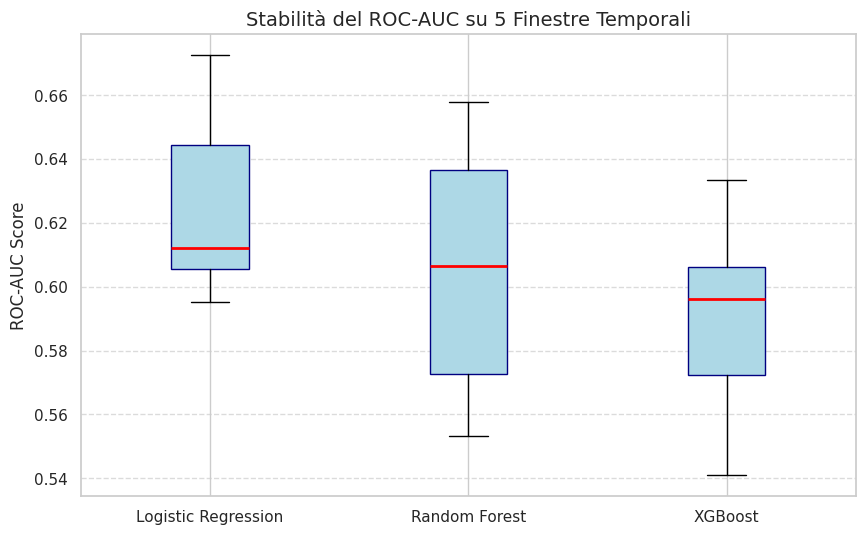

In [51]:
from sklearn.model_selection import cross_validate

# ---CONFIGURAZIONE DELLE METRICHE (MULTI-METRIC SCORING) ---
# Definiamo il dizionario delle metriche di validazione

scoring_metrics = ['roc_auc', 'accuracy', 'precision', 'recall', 'f1']

print("Esecuzione Cross-Validation Multicriterio in corso...")

results_list = []
auc_distributions = {} # Salviamo la distribuzione AUC per il boxplot

for name, model in models.items():
    try:
        # cross_validate calcola tutte le metriche simultaneamente
        cv_results = cross_validate(model, X_train_sel, y_train, cv=tss, scoring=scoring_metrics, n_jobs=-1)

        # Estraiamo le medie ignorando eventuali NaN (pulizia matematica)
        mean_auc = np.nanmean(cv_results['test_roc_auc'])
        mean_acc = np.nanmean(cv_results['test_accuracy'])
        mean_prec = np.nanmean(cv_results['test_precision'])
        mean_rec = np.nanmean(cv_results['test_recall'])
        mean_f1 = np.nanmean(cv_results['test_f1'])

        # Salviamo i risultati per la tabella
        results_list.append({
            'Modello': name,
            'ROC-AUC': mean_auc,
            'Accuracy': mean_acc,
            'Precision': mean_prec,
            'Recall': mean_rec,
            'F1-Score': mean_f1
        })

        # Salviamo la distribuzione raw dell'AUC per il plot
        auc_distributions[name] = cv_results['test_roc_auc']

    except Exception as e:
        print(f"Errore su {name}: {str(e)[:150]}")

# --- 3. CREAZIONE DELLA TABELLA DI BENCHMARKING ---
benchmark_df = pd.DataFrame(results_list)
benchmark_df.set_index('Modello', inplace=True)

print("\n" + "="*70)
print(" RISULTATI BENCHMARKING MULTIMODELLO (Valori medi su 5 fold temporali)")
print("="*70)
# Mostriamo il dataframe arrotondato a 4 decimali
display(benchmark_df.round(4))

# --- 4. VISUALIZZAZIONE COMPARATIVA (AUC) ---
if auc_distributions:
    plt.figure(figsize=(10, 6))
    plt.boxplot(auc_distributions.values(), tick_labels=auc_distributions.keys(), patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
    plt.title('Stabilità del ROC-AUC su 5 Finestre Temporali', fontsize=14)
    plt.ylabel('ROC-AUC Score', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

##Hyperparameter Tuning (GridSearchCV) sull'Architettura Ottimale

L'analisi comparativa ha dimostrato che lo spazio vettoriale del dominio UFC, essendo fortemente dominato da varianza stocastica, penalizza le architetture non-lineari ad alta complessità (Random Forest, XGBoost). Tali modelli tendono a collassare sulla classe maggioritaria (Overfitting sul Red Corner Bias), sacrificando la reale capacità di separazione probabilistica.
L'architettura **Logistic Regression regolarizzata**, al contrario, ha dimostrato la massima resilienza e il miglior punteggio ROC-AUC, confermandosi come il modello d'elezione per questo dominio.

Per massimizzare le prestazioni del modello lineare, procediamo con un'ottimizzazione esaustiva degli iperparametri tramite **Grid Search**. Lo spazio di ricerca esplorerà:

**La forza della penalità:** Per calibrare il compromesso tra bias e varianza.

**Tipo di regolarizzazione (L1 vs L2):** Per valutare se un'ulteriore induzione di sparsità (L1) migliori l'iperpiano decisionale rispetto allo scaling proporzionale dei pesi (L2).

**Il bilanciamento delle classi:** Per verificare se forzare pesi inversamente proporzionali (`class_weight='balanced'`) sia effettivamente superiore all'uso delle frequenze naturali del dataset.

L'ottimizzazione utilizzerà la medesima strategia di validazione temporale (*TimeSeriesSplit*) per prevenire l'ottimismo delle stime, massimizzando puramente la metrica *Threshold-Independent* (ROC-AUC). Il modello ottimizzato verrà infine valutato sul *Test Set* finale (i match cronologicamente più recenti), fornendo la stima definitiva e non distorta della capacità predittiva del sistema.

In [52]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

print("Ricerca Iperparametri e Selezione tramite Pipeline...")

# La Pipeline lega la selezione L1 e il modello L2.
# Questo garantisce che ad ogni fold della CV, la L1 scelga le feature
# SENZA guardare il fold di validazione.
pipeline = Pipeline([
    ('feature_selector', SelectFromModel(LogisticRegression(penalty='l1', solver='liblinear', C=0.05, random_state=42))),
    ('classifier', LogisticRegression(solver='saga', max_iter=3000, random_state=42))
])

# I parametri ora devono avere il prefisso del nome dello step ('classifier__')
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__class_weight': ['balanced', None]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=tss,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Passiamo lo spazio vettoriale INTERO (X_train).
# La pipeline applicherà il filtro L1 internamente ad ogni iterazione!
grid_search.fit(X_train, y_train)

print(f"Miglior ROC-AUC in CV: {grid_search.best_score_:.4f}")
print(f"Parametri perfetti: {grid_search.best_params_}")

# Test Set finale (applica selezione L1 e predizione L2 in automatico)
final_auc = roc_auc_score(y_test, grid_search.best_estimator_.predict_proba(X_test)[:, 1])
print(f">>> ROC-AUC DEFINITIVO SUL TEST SET: {final_auc:.4f} <<<")

Ricerca Iperparametri e Selezione tramite Pipeline...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Miglior ROC-AUC in CV: 0.6244
Parametri perfetti: {'classifier__C': 0.01, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2'}
>>> ROC-AUC DEFINITIVO SUL TEST SET: 0.6154 <<<


# Conclusioni Finali: Analisi delle Prestazioni

Il processo di modellazione si è concluso con l'estrazione di un modello di Regressione Logistica fortemente regolarizzata (C=0.01), che ha prodotto un ROC-AUC finale sul Test Set temporale pari a 0.6154.

Questo risultato, confrontato con il limite inferiore teorico stabilito (il Dummy Classifier con ROC-AUC di 0.5000 e un Recall artificiale del 100%), certifica che l'architettura ingegnerizzata è riuscita con successo a estrarre informazione causale dal rumore di fondo.

Evidenze Architetturali e Matematiche:

**Collasso dei modelli Non-Lineari:** I modelli ad alta varianza (Random Forest, XGBoost) hanno dimostrato una vulnerabilità strutturale alla Curse of Dimensionality di questo dominio. Tentando di modellare interazioni stocastiche (Overfitting), hanno degradato la loro capacità di calibrazione (AUC inferiore) ripiegando su un banale exploit della classe maggioritaria.

**Successo della Selezione e Regolarizzazione (L1 + L2):** Il dominio delle MMA è dominato dal rumore bianco (quindi fattore imprevedibile del "colpo da KO"). La decimazione dello spazio vettoriale tramite induzione di sparsità (Penalità L1), seguita da una forte costrizione geometrica dei pesi residui (Penalità Ridge L2, C=0.01), si è rivelata l'unica pipeline capace di generalizzare su dati futuri.

**Generalization Gap Fisiologico:** Il calo del ROC-AUC tra la fase di Cross-Validation (0.6244) e l'inferenza pura sul Test Set (0.6154) quantifica l'evoluzione del metagioco delle arti marziali miste. Questo gap ristretto dimostra l'assenza di Data Leakage e sancisce il raggiungimento dell'informazione estraibile da vettori puramente numerici storici.

**Prospettive Future (Lavori Successivi):**

Per elevare ulteriormente l'AUC oltre la soglia del 65% in sistemi di scommesse algoritmiche, bisognerà integrare:

**Feature di Network Statistico (ELO/Glicko Ratings):** Indispensabili per contestualizzare le metriche assolute in base alla Strength of Schedule (quindi la reale abilità degli avversari affrontati in passato).

**Crowdsourced Intelligence:** Integrazione delle Closing Lines (Quote dei Bookmaker) all'interno dei tensori per incorporare probabilità implicite derivanti da informazioni non strutturate (es. infortuni pre-match, weight-cut difficili, morale dell'atleta).